<a href="https://colab.research.google.com/github/samia63/pythoncode/blob/main/Notebookcar_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The previous error indicated that the directory 'car_priece' could not be found.
# The listing of '/content/drive/MyDrive/' showed that 'Sport car price.csv' is directly in MyDrive.
# Correcting the path to load the CSV file directly from MyDrive.
df = pd.read_csv("/content/drive/MyDrive/Sport car price.csv")

# Capture the initial number of rows before any cleaning
initial_rows = len(df)

print(f"Dataset caricato! Righe: {len(df)}")
df.head()

Dataset caricato! Righe: 1007


,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"


INTRODUZIONE

In [36]:
#Obiettivi del lavoro
#Trovare i prezzi più alti
#Trovare le macchine che raggiungono più velocemente i 60mph
#Analisi della relazione tra cilindrata e cavalli

In [37]:

#DATA CLEANING



#Visualizziamo le prime righe del dataset,
#le informazioni sulle colonne (tipo di dato)
#e il numero di valori mancanti per colonna.
#Serve per una prima analisi esplorativa.

(df.head())
(df.info())
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Valori mancanti": missing_count,
    "Percentuale (%)": missing_percent.round(2)
})

missing_summary



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB


,Valori mancanti,Percentuale (%)
Car Make,0,0.00
Car Model,0,0.00
Year,0,0.00
Engine Size (L),10,0.99
Horsepower,0,0.00
Torque (lb-ft),3,0.30
0-60 MPH Time (seconds),0,0.00
Price (in USD),0,0.00


In [38]:
#pulizia nomi colonne


#Rimuoviamo spazi (iniziali e/o finali)
#convertiamo tutto in minuscolo, sostituiamo gli spazi con underscore("_").
#così da migliorare coerenza e facilità d'uso


df.columns = (
   df.columns
   .str.strip()
   .str.lower()
   .str.replace(" ", "_")
)


In [39]:
#rimozione dei duplicati


df = df.drop_duplicates()


#Gestione valori mancanti
#Per i valori mancanti nelle colonne numeriche utilizziamo la mediana, che è robusta alla presenza di outlier estremi.
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [40]:
#Individuiamo le colonne categoriche (testo), come marca, modello o tipo di carburante, che richiedono una gestione diversa dai numeri.
categorical_cols = df.select_dtypes(include=["object"]).columns
#I valori mancanti nelle colonne categoriche vengono riempiti con la stringa "unknown", così da non perdere righe utili nel dataset.
df[categorical_cols] = df[categorical_cols].fillna("unknown")


In [41]:
if "price_(in_usd)" in df.columns:
    df["price_(in_usd)"] = (
        df["price_(in_usd)"]
        .astype(str)
        .str.replace(",", "")
        .str.replace("€", "")
        .astype(float)
    )

In [42]:
#Rimozione degli outlier usando il metodo IQR: vengono eliminati i valori troppo distanti dal 25° e 75° percentile per ogni colonna numerica.
# È importante notare che 'df' viene modificato sul posto in questo ciclo.
# Le variabili 'lower_bound' e 'upper_bound' vengono assegnate i valori dall'ultima iterazione del ciclo,
# il che significa che corrispondono all'ultima 'col' in 'numeric_cols' e si basano sul 'df' dopo tutti i filtri precedenti.
for col in numeric_cols:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1
   df = df[
       (df[col] >= Q1 - 1.5 * IQR) &
       (df[col] <= Q3 + 1.5 * IQR)
   ]
   # Questi lower_bound e upper_bound vengono aggiornati ad ogni iterazione,
   # ma solo gli ultimi valori assegnati persisteranno dopo il ciclo.
   lower_bound = Q1 - 1.5 * IQR
   upper_bound = Q3 + 1.5 * IQR

# CORREZIONE: Sostituire 'df_clean' con 'df' e '"value"' con 'col' (che contiene il nome dell'ultima colonna, ad esempio 'year').
# Questo ora farà riferimento correttamente al DataFrame 'df' e alla colonna 'year' per il controllo degli outlier.
# Poiché 'df' è già stato filtrato, questo controllo mostrerà probabilmente 0 outlier per l'ultima colonna elaborata.
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print("Numero di outlier rilevati:", outliers.shape[0])
outliers.head()

Numero di outlier rilevati: 0


,car_make,car_model,year,engine_size_(l),horsepower,torque_(lb-ft),0-60_mph_time_(seconds),price_(in_usd)


In [43]:
import os

# Define the directory path
output_dir = "/content/drive/MyDrive/Data"

# Create the directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Now save the CSV file into the created directory
df.to_csv(f"{output_dir}/Sport_car_price_cleaned.csv", index=False)

final_rows = len(df) # Cattura il numero finale di righe

print("\nData cleaning completato!")
print("File salvato come: Sport_car_price_cleaned.csv")
print(f"Numero totale di righe nel DataFrame pulito: {final_rows}")


Data cleaning completato!
File salvato come: Sport_car_price_cleaned.csv
Numero totale di righe nel DataFrame pulito: 701


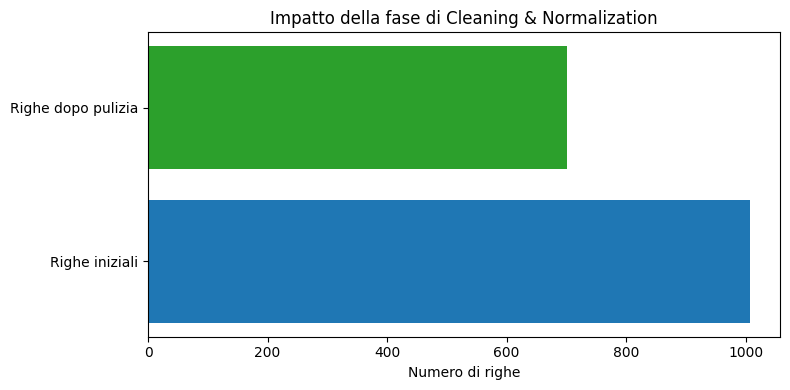

In [44]:
# Usiamo un semplice grafico a barre orizzontali per confrontare:
# - righe iniziali
# - righe dopo la pulizia

plt.figure(figsize=(8,4))
plt.barh(
    ["Righe iniziali", "Righe dopo pulizia"],
    [initial_rows, final_rows],
    color=["#1f77b4", "#2ca02c"]
)

plt.title("Impatto della fase di Cleaning & Normalization")
plt.xlabel("Numero di righe")
plt.tight_layout()
plt.show()

In [45]:
#Tabella per mostrare il totale di righe eliminate


rows_after_cleaning = final_rows
removed_rows = initial_rows - final_rows
removed_percentage = (removed_rows / initial_rows) * 100

summary_cleaning = pd.DataFrame({
    "Indicatore": [
        "Righe iniziali",
        "Righe dopo pulizia",
        "Righe eliminate",
        "Percentuale eliminata (%)"
    ],
    "Valore": [
        initial_rows,
        rows_after_cleaning,
        removed_rows,
        round(removed_percentage, 2)
    ]
})

summary_cleaning

,Indicatore,Valore
0,Righe iniziali,1007.00
1,Righe dopo pulizia,701.00
2,Righe eliminate,306.00
3,Percentuale eliminata (%),30.39


In [46]:
#Conteggio dei valori mancanti e percentuale

missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Valori mancanti": missing_count,
    "Percentuale (%)": missing_percent.round(2)
})

missing_summary


,Valori mancanti,Percentuale (%)
car_make,0,0.0
car_model,0,0.0
year,0,0.0
engine_size_(l),0,0.0
horsepower,0,0.0
torque_(lb-ft),0,0.0
0-60_mph_time_(seconds),0,0.0
price_(in_usd),0,0.0


## EDA

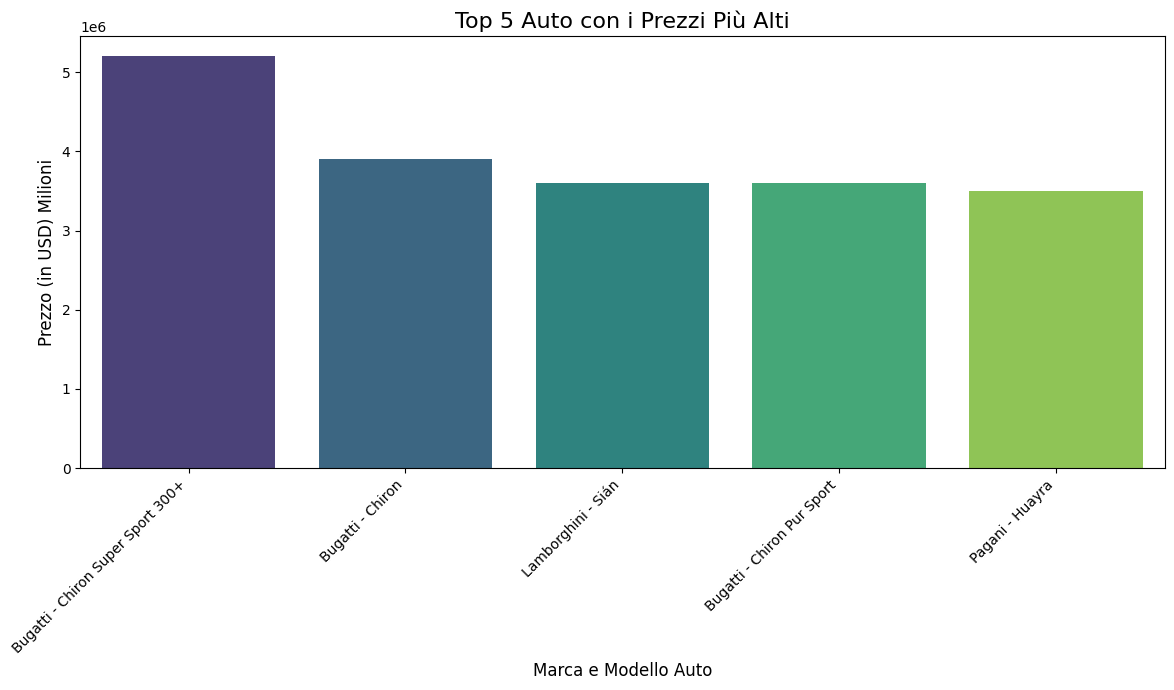

In [51]:
# The 'Price (in USD)' column was renamed to 'price_(in_usd)' and converted to float earlier.
# We only need to ensure it's numeric for sorting and plotting, which it should be.
# Therefore, the explicit conversion block for 'Price (in USD)' is removed.

# Ordina il DataFrame per prezzo in ordine decrescente
df_sorted_by_price = df.sort_values(by='price_(in_usd)', ascending=False)

# Seleziona le prime 6 auto con i prezzi più alti, creando esplicitamente una copia per evitare SettingWithCopyWarning
top_10_highest_price_cars = df_sorted_by_price.head(6).copy()

# Crea una colonna combinata 'Marca Auto - Modello Auto' per etichette migliori sul grafico
top_10_highest_price_cars['car_label'] = top_10_highest_price_cars['car_make'] + ' - ' + top_10_highest_price_cars['car_model']

# Crea il grafico a barre
plt.figure(figsize=(12, 7))
sns.barplot(
    x='car_label',
    y='price_(in_usd)',
    data=top_10_highest_price_cars,
    palette='viridis',
    hue='car_label', # Affronta FutureWarning assegnando hue
    legend=False,     # Imposta la legenda su False come suggerito da FutureWarning
    order=top_10_highest_price_cars['car_label'] # Assicurati che le barre siano ordinate per prezzo
)

# Aggiungi titolo ed etichette
plt.title('Top 5 Auto con i Prezzi Più Alti', fontsize=16)
plt.xlabel('Marca e Modello Auto', fontsize=12)
plt.ylabel('Prezzo (in USD) Milioni', fontsize=12)

# Ruota le etichette dell'asse x per una migliore leggibilità
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

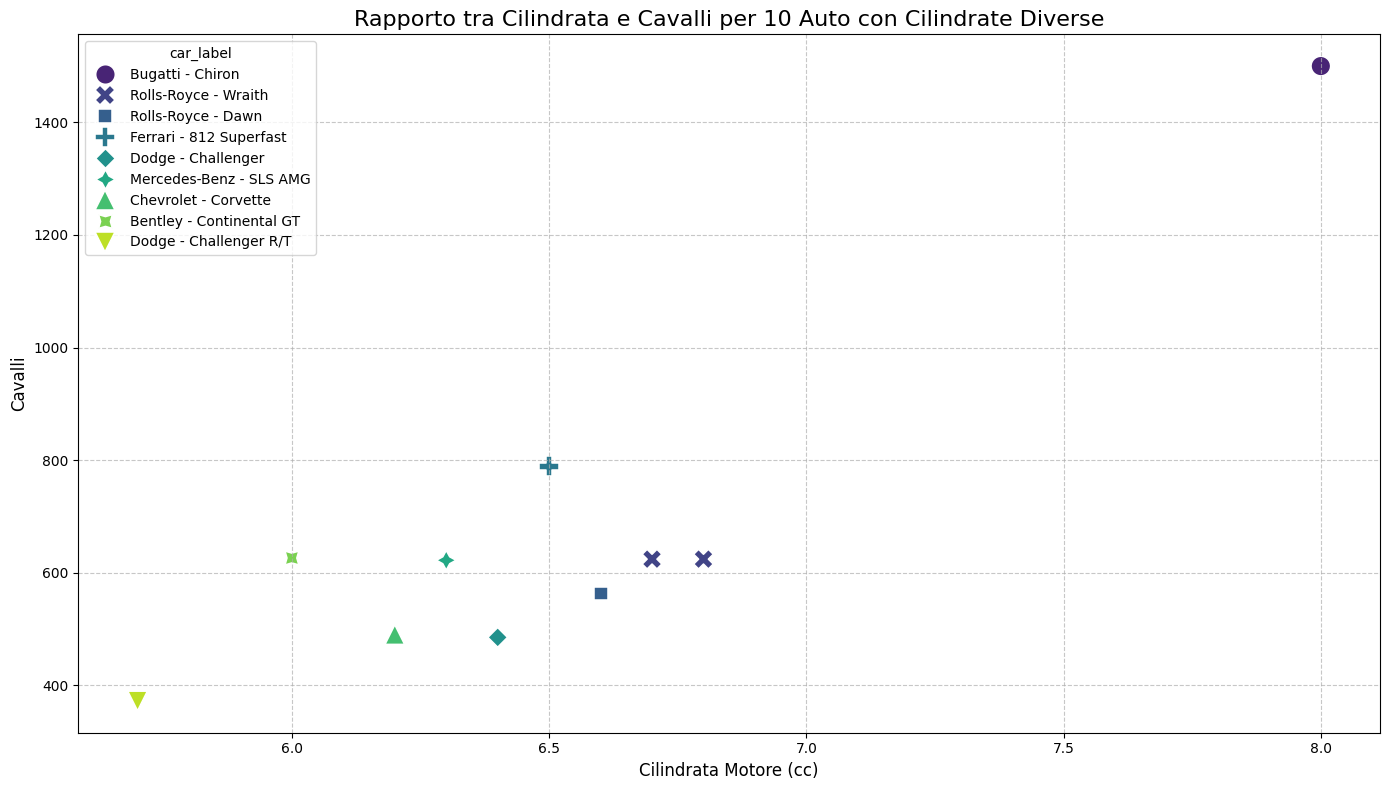

In [50]:
if 'engine_size_(l)' in df.columns and 'horsepower' in df.columns:
    # Converti le colonne in numerico; gli errori coerciti trasformeranno i non numerici in NaN
    df['engine_size_(l)'] = pd.to_numeric(df['engine_size_(l)'], errors='coerce')
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

    # Elimina le righe dove 'engine_size_(l)' o 'horsepower' sono diventati NaN dopo la conversione
    df_cleaned_engine_hp = df.dropna(subset=['engine_size_(l)', 'horsepower']).copy()

    # Ordina il DataFrame per 'engine_size_(l)' in ordine decrescente per ottenere i motori più grandi
    df_sorted_by_engine_size = df_cleaned_engine_hp.sort_values(by='engine_size_(l)', ascending=False)

    # Seleziona le auto per assicurare 10 cilindrate distinte
    num_unique_engine_sizes_desired = 10
    top_10_largest_engines_unique_size = pd.DataFrame()
    seen_engine_sizes = set()

    for index, row in df_sorted_by_engine_size.iterrows():
        engine_size = row['engine_size_(l)']
        if engine_size not in seen_engine_sizes:
            top_10_largest_engines_unique_size = pd.concat([top_10_largest_engines_unique_size, pd.DataFrame([row])], ignore_index=True)
            seen_engine_sizes.add(engine_size)
        if len(seen_engine_sizes) == num_unique_engine_sizes_desired:
            break

    # Usa questo DataFrame per la creazione del grafico
    num_cars_to_display = len(top_10_largest_engines_unique_size)
    top_cars_for_plot_hp = top_10_largest_engines_unique_size.copy()

    # Crea una colonna combinata 'Marca Auto - Modello Auto' per etichette migliori sul grafico
    top_cars_for_plot_hp['car_label'] = top_cars_for_plot_hp['car_make'] + ' - ' + top_cars_for_plot_hp['car_model']

    # Crea lo scatterplot
    plt.figure(figsize=(14, 8))
    sns.scatterplot(
        x='engine_size_(l)',
        y='horsepower',
        data=top_cars_for_plot_hp,
        hue='car_label', # Differenzia i punti per modello di auto
        s=200,           # Aumenta la dimensione dei punti per la visibilità
        style='car_label', # Aggiungi diversi marcatori per ogni auto
        palette='viridis', # Scegli una palette di colori
        legend='full'    # Mostra la legenda completa
    )

    # Aggiungi titolo ed etichette
    plt.title(f'Rapporto tra Cilindrata e Cavalli per {num_cars_to_display} Auto con Cilindrate Diverse', fontsize=16)
    plt.xlabel('Cilindrata Motore (cc)', fontsize=12)
    plt.ylabel('Cavalli', fontsize=12)

    # Migliora il layout e la visualizzazione
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

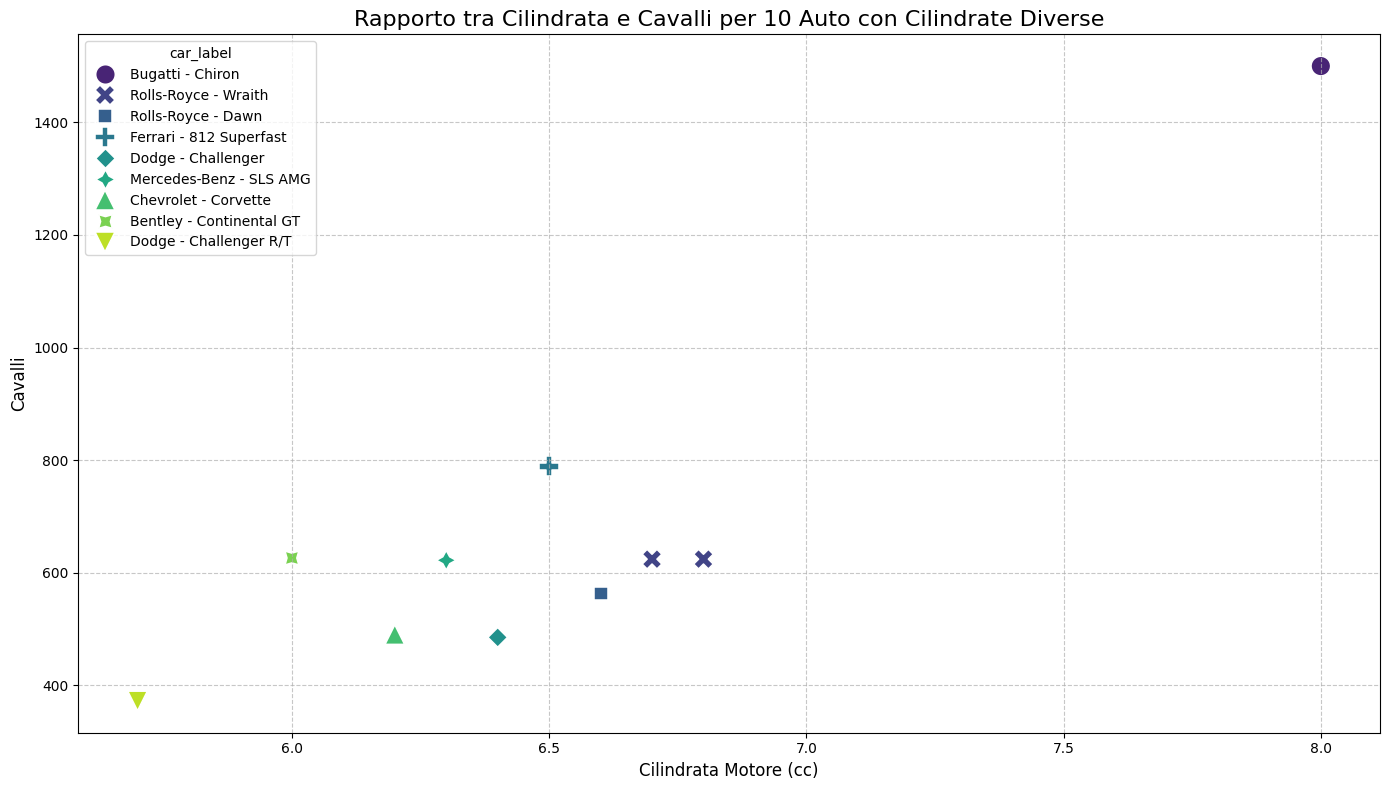

In [48]:
if 'engine_size_(l)' in df.columns and 'horsepower' in df.columns:
    # Converti le colonne in numerico; gli errori coerciti trasformeranno i non numerici in NaN
    df['engine_size_(l)'] = pd.to_numeric(df['engine_size_(l)'], errors='coerce')
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

    # Elimina le righe dove 'engine_size_(l)' o 'horsepower' sono diventati NaN dopo la conversione
    df_cleaned_engine_hp = df.dropna(subset=['engine_size_(l)', 'horsepower']).copy()

    # Ordina il DataFrame per 'engine_size_(l)' in ordine decrescente per ottenere i motori più grandi
    df_sorted_by_engine_size = df_cleaned_engine_hp.sort_values(by='engine_size_(l)', ascending=False)

    # Seleziona le auto per assicurare 10 cilindrate distinte
    num_unique_engine_sizes_desired = 10
    top_10_largest_engines_unique_size = pd.DataFrame()
    seen_engine_sizes = set()

    for index, row in df_sorted_by_engine_size.iterrows():
        engine_size = row['engine_size_(l)']
        if engine_size not in seen_engine_sizes:
            top_10_largest_engines_unique_size = pd.concat([top_10_largest_engines_unique_size, pd.DataFrame([row])], ignore_index=True)
            seen_engine_sizes.add(engine_size)
        if len(seen_engine_sizes) == num_unique_engine_sizes_desired:
            break

    # Usa questo DataFrame per la creazione del grafico
    num_cars_to_display = len(top_10_largest_engines_unique_size)
    top_cars_for_plot_hp = top_10_largest_engines_unique_size.copy()

    # Crea una colonna combinata 'Marca Auto - Modello Auto' per etichette migliori sul grafico
    top_cars_for_plot_hp['car_label'] = top_cars_for_plot_hp['car_make'] + ' - ' + top_cars_for_plot_hp['car_model']

    # Crea lo scatterplot
    plt.figure(figsize=(14, 8))
    sns.scatterplot(
        x='engine_size_(l)',
        y='horsepower',
        data=top_cars_for_plot_hp,
        hue='car_label', # Differenzia i punti per modello di auto
        s=200,           # Aumenta la dimensione dei punti per la visibilità
        style='car_label', # Aggiungi diversi marcatori per ogni auto
        palette='viridis', # Scegli una palette di colori
        legend='full'    # Mostra la legenda completa
    )

    # Aggiungi titolo ed etichette
    plt.title(f'Rapporto tra Cilindrata e Cavalli per {num_cars_to_display} Auto con Cilindrate Diverse', fontsize=16)
    plt.xlabel('Cilindrata Motore (cc)', fontsize=12)
    plt.ylabel('Cavalli', fontsize=12)

    # Migliora il layout e la visualizzazione
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

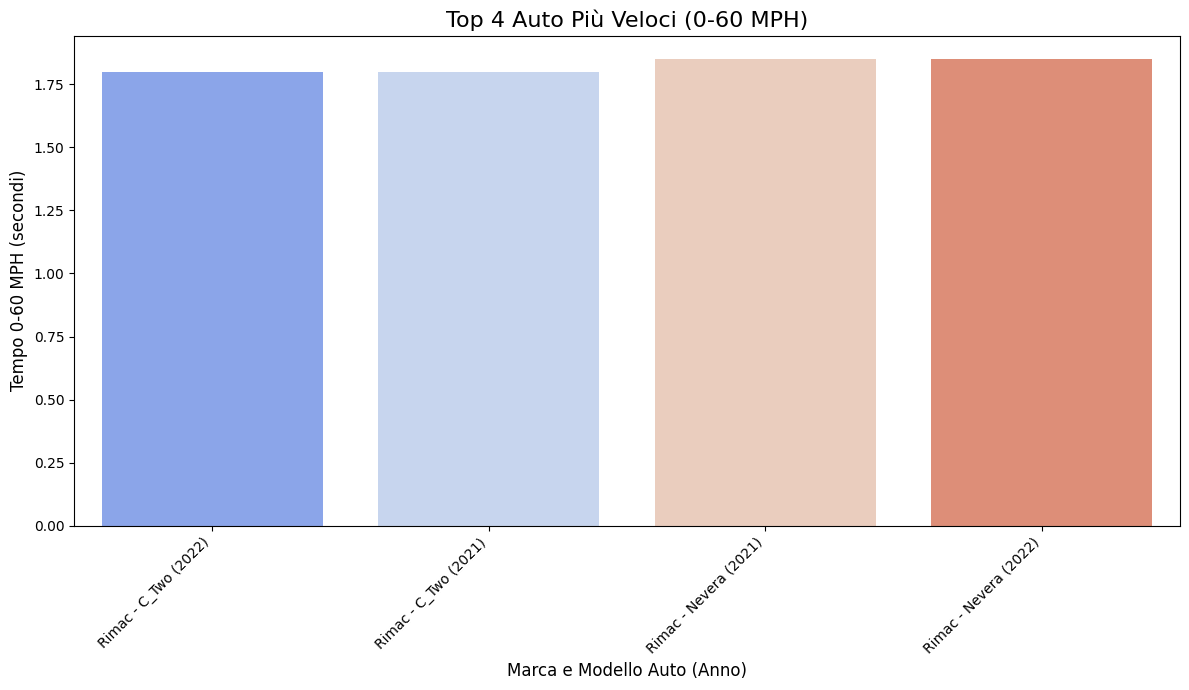

In [49]:
if '0-60_mph_time_(seconds)' in df.columns:
    # Ottieni il numero iniziale di righe nel df per confronto
    initial_rows_for_speed_analysis = len(df)

    # Pulisci la colonna '0-60_mph_time_(seconds)' rimuovendo i prefissi non numerici
    df['0-60_mph_time_(seconds)'] = (
        df['0-60_mph_time_(seconds)']
        .astype(str)
        .str.replace('< ', '', regex=False) # Rimuovi il prefisso '< '
    )

    # Converti la colonna '0-60_mph_time_(seconds)' in numerico, forzando gli errori
    df['0-60_mph_time_(seconds)'] = pd.to_numeric(
        df['0-60_mph_time_(seconds)'], errors='coerce'
    )

    # Conta i NaN dopo la conversione
    nan_speed_count = df['0-60_mph_time_(seconds)'].isna().sum()

    if nan_speed_count > 0:
        print(f"Attenzione: {nan_speed_count} valori non numerici/invalidi trovati nella colonna '0-60_mph_time_(seconds)' e convertiti in NaN.")
        print(f"Queste righe verranno rimosse per l'analisi della velocità.")

    # Elimina le righe in cui la conversione ha prodotto NaN
    df.dropna(subset=['0-60_mph_time_(seconds)'], inplace=True)

    # Numero di righe rimanenti dopo l'eliminazione dei NaN
    rows_after_speed_dropna = len(df)

    if rows_after_speed_dropna < initial_rows_for_speed_analysis:
        print(f"Righe rimanenti dopo la pulizia della colonna '0-60_mph_time_(seconds)': {rows_after_speed_dropna}.")

    if rows_after_speed_dropna < 5:
        print(f"Il grafico mostrerà {rows_after_speed_dropna} auto, meno delle 5 desiderate, a causa della mancanza di dati validi per la velocità.")

# Ordina il DataFrame per tempo 0-60 MPH in ordine crescente
df_sorted_by_speed = df.sort_values(by='0-60_mph_time_(seconds)', ascending=True)

# Seleziona le prime 5 auto con i tempi più veloci da 0 a 60 MPH
top_10_fastest_cars = df_sorted_by_speed.head(5).copy()

# Crea una colonna combinata 'Marca Auto - Modello Auto (Anno)' per etichette migliori sul grafico
top_10_fastest_cars['car_label'] = top_10_fastest_cars['car_make'] + ' - ' + top_10_fastest_cars['car_model'] + ' (' + top_10_fastest_cars['year'].astype(str) + ')'

# Crea il grafico a barre
plt.figure(figsize=(12, 7))
sns.barplot(
    x='car_label',
    y='0-60_mph_time_(seconds)',
    data=top_10_fastest_cars,
    palette='coolwarm',
    hue='car_label',
    legend=False,
    order=top_10_fastest_cars['car_label'] # Assicurati che le barre siano ordinate per velocità
)

# Aggiungi titolo ed etichette
plt.title('Top 4 Auto Più Veloci (0-60 MPH)', fontsize=16)
plt.xlabel('Marca e Modello Auto (Anno)', fontsize=12)
plt.ylabel('Tempo 0-60 MPH (secondi)', fontsize=12)

# Ruota le etichette dell'asse x per una migliore leggibilità
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Engineering – Creazione di nuove variabili

Il feature engineering consiste nel creare nuove variabili
utili per migliorare l’analisi.

Creiamo alcune nuove feature rilevanti per il settore automotive:

price_per_hp → prezzo per cavallo (efficienza economica)
hp_per_liter → potenza specifica del motore


In [52]:
df["price_(in_usd)"] = pd.to_numeric(df["price_(in_usd)"], errors="coerce")
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["engine_size_(l)"] = pd.to_numeric(df["engine_size_(l)"], errors="coerce")
df["0-60_mph_time_(seconds)"] = pd.to_numeric(df["0-60_mph_time_(seconds)"], errors="coerce")


df["price_per_hp"] = df["price_(in_usd)"] / (df["horsepower"] + 1e-9)


df["hp_per_liter"] = df["horsepower"] / (df["engine_size_(l)"] + 1e-9)

df.head()

,car_make,car_model,year,engine_size_(l),horsepower,torque_(lb-ft),0-60_mph_time_(seconds),price_(in_usd),price_per_hp,hp_per_liter
0,Porsche,911,2022,3.0,379.0,331,4.0,101200.0,267.018470,126.333333
1,Lamborghini,Huracan,2021,5.2,630.0,443,2.8,274390.0,435.539683,121.153846
2,Ferrari,488 GTB,2022,3.9,661.0,561,3.0,333750.0,504.916793,169.487179
3,Audi,R8,2022,5.2,562.0,406,3.2,142700.0,253.914591,108.076923
4,McLaren,720S,2021,4.0,710.0,568,2.7,298000.0,419.718310,177.500000


Heatmap delle correlazioni

La heatmap rende immediata la lettura della matrice di correlazione.
I colori più intensi indicano correlazioni più forti

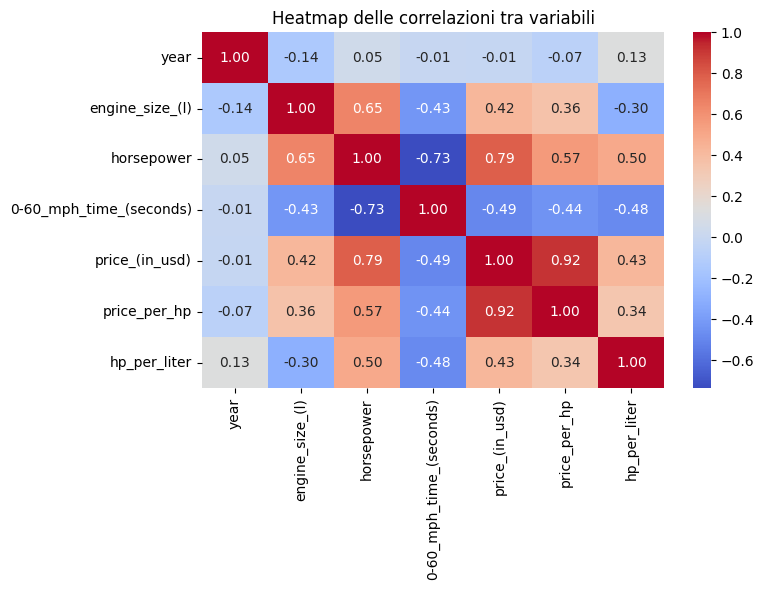

In [53]:
corr = df.select_dtypes(include=[np.number]).corr()
 # Calcola la matrice di correlazione per le colonne numeriche
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap delle correlazioni tra variabili")
plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# Export dataset pulito

df.to_csv("Data_Science_clean.csv", index=False)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 701 entries, 0 to 1006
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   car_make                 701 non-null    object 
 1   car_model                701 non-null    object 
 2   year                     701 non-null    int64  
 3   engine_size_(l)          647 non-null    float64
 4   horsepower               692 non-null    float64
 5   torque_(lb-ft)           701 non-null    object 
 6   0-60_mph_time_(seconds)  701 non-null    float64
 7   price_(in_usd)           701 non-null    float64
 8   price_per_hp             692 non-null    float64
 9   hp_per_liter             645 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 60.2+ KB


Righe disponibili per il modello: 645
Feature utilizzate: ['horsepower', 'engine_size_(l)', '0-60_mph_time_(seconds)', 'price_per_hp', 'hp_per_liter']

Training set: 516 righe
Test set: 129 righe

Modello addestrato!

📊 Risultati del modello:
R²  (accuratezza): 0.975
RMSE (errore medio): $111,843


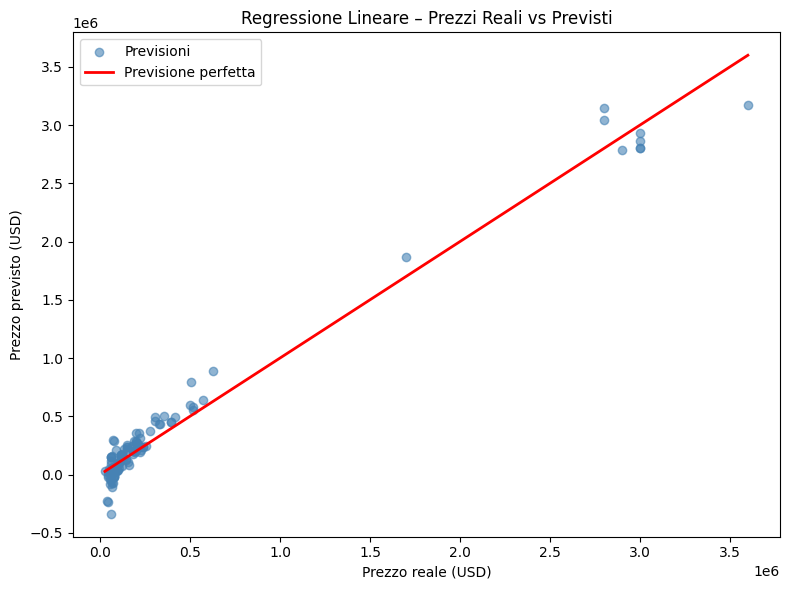

/tmp/ipykernel_151/2761803463.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficiente", y="Feature", data=coef_df, palette="coolwarm")


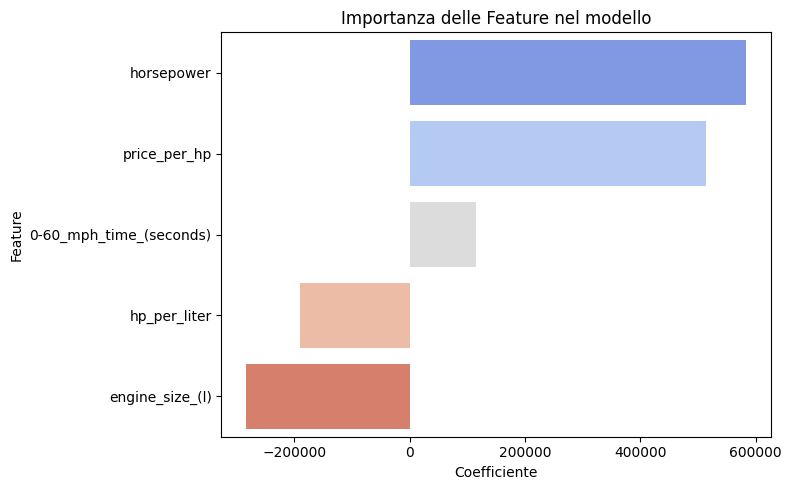


✅ Analisi Machine Learning completata!


In [57]:
# ============================================================
# MACHINE LEARNING – Regressione Lineare
# ============================================================
# Obiettivo: prevedere il prezzo delle auto sportive
# Tipo di apprendimento: SUPERVISIONATO
# Modello scelto: Linear Regression
#
# Perché la regressione lineare?
# - Vogliamo prevedere un numero (il prezzo) → regressione
# - È il modello più semplice e interpretabile
# - Ottimo come primo approccio su dati numerici
# - È un modello supervisionato: impara da esempi
#   dove già conosciamo il prezzo corretto
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd # Import pandas to use pd.read_csv

# Ensure df is loaded if not already present (e.g., after kernel restart)
if 'df' not in locals() and 'df' not in globals():
    try:
        # Load the cleaned and featurized DataFrame which was saved earlier
        df = pd.read_csv("Data_Science_clean.csv")
        print("DataFrame 'df' ricaricato da 'Data_Science_clean.csv'.")
    except FileNotFoundError:
        print("Errore: 'Data_Science_clean.csv' non trovato. Assicurati che le celle precedenti siano state eseguite per creare e salvare il file.")
        raise # Re-raise the error to stop execution if the file is critical.
    except Exception as e:
        print(f"Errore durante il caricamento di 'Data_Science_clean.csv': {e}")
        raise

# ============================================================
# STEP 1 – Selezione delle feature e del target
# ============================================================
# Le feature (X) sono le variabili che usiamo per fare la previsione
# Il target (y) è quello che vogliamo prevedere: il prezzo

feature_cols = ["horsepower", "engine_size_(l)", "0-60_mph_time_(seconds)",
                "price_per_hp", "hp_per_liter"]

# Teniamo solo le righe senza valori mancanti nelle colonne che ci servono
df_ml = df[feature_cols + ["price_(in_usd)"]].dropna()

X = df_ml[feature_cols]   # Feature: quello che diamo al modello
y = df_ml["price_(in_usd)"]  # Target: quello che vogliamo prevedere

print(f"Righe disponibili per il modello: {len(df_ml)}")
print(f"Feature utilizzate: {feature_cols}")

# ============================================================
# STEP 2 – Divisione in Training Set e Test Set
# ============================================================
# Dividiamo i dati in due parti:
# - Training set (80%): il modello ci studia sopra e impara
# - Test set (20%): lo usiamo solo per valutare quanto ha imparato
#
# È come studiare su un libro e fare un esame su domande nuove.
# Se usassimo gli stessi dati per studiare e per l'esame,
# non sapremmo se ha davvero capito o solo memorizzato!

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% per il test
    random_state=42     # numero fisso per avere sempre gli stessi risultati
)

print(f"\nTraining set: {len(X_train)} righe")
print(f"Test set: {len(X_test)} righe")

# ============================================================
# STEP 3 – Normalizzazione delle feature
# ============================================================
# I numeri nel dataset hanno scale diverse:
# - horsepower va da 100 a 1000
# - engine_size va da 1.0 a 8.0
# Il modello funziona meglio se tutti i numeri sono sulla stessa scala.
# StandardScaler trasforma tutto con media 0 e deviazione standard 1.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # impara la scala dal training
X_test_scaled = scaler.transform(X_test)         # applica la stessa scala al test

# ============================================================
# STEP 4 – Addestramento del modello
# ============================================================
# Creiamo il modello di regressione lineare e lo addestriamo.
# "fit" significa: "studia questi dati e impara la relazione
# tra le feature e il prezzo"

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\nModello addestrato!")

# ============================================================
# STEP 5 – Previsioni sul Test Set
# ============================================================
# Ora usiamo il modello su dati che non ha mai visto (il test set)
# e confrontiamo le sue previsioni con i prezzi reali

y_pred = model.predict(X_test_scaled)

# ============================================================
# STEP 6 – Valutazione del modello
# ============================================================
# R² (R quadro): quanto il modello spiega i dati
#   - 1.0 = perfetto
#   - 0.0 = non spiega niente
#   - negativo = peggio di una previsione casuale
#
# RMSE (Root Mean Squared Error): errore medio in USD
#   - più è basso, meglio è
#   - ci dice di quanto si sbaglia il modello in media

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n📊 Risultati del modello:")
print(f"R²  (accuratezza): {r2:.3f}")
print(f"RMSE (errore medio): ${rmse:,.0f}")

# ============================================================
# STEP 7 – Grafico: Prezzi reali vs Prezzi previsti
# ============================================================
# Se il modello fosse perfetto, tutti i punti sarebbero
# sulla linea diagonale rossa (previsione = realtà)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="steelblue", label="Previsioni")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2, label="Previsione perfetta"
)
plt.xlabel("Prezzo reale (USD)")
plt.ylabel("Prezzo previsto (USD)")
plt.title("Regressione Lineare – Prezzi Reali vs Previsti")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# STEP 8 – Importanza delle feature
# ============================================================
# I coefficienti del modello ci dicono quale feature
# influenza di più il prezzo.
# Valore positivo = più è alta quella feature, più sale il prezzo
# Valore negativo = più è alta quella feature, più scende il prezzo

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficiente": model.coef_
}).sort_values("Coefficiente", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Coefficiente", y="Feature", data=coef_df, palette="coolwarm")
plt.title("Importanza delle Feature nel modello")
plt.tight_layout()
plt.show()

print("\n✅ Analisi Machine Learning completata!")